In [3]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import numpy               as np
if not hasattr(np, 'warnings'):
    np.warnings = np
if not hasattr(np, 'filterwarnings'):
    np.filterwarnings = lambda *args, **kwargs: None
import pandas              as pd
import seaborn             as sbn
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections                      import Counter
from sklearn.preprocessing            import LabelEncoder
from pyclustering.cluster.kmedoids    import kmedoids
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from sklearn.preprocessing     import LabelEncoder
from sklearn.metrics           import pairwise_distances
from Customer_dataset import data_scaled    
processed_data=data_scaled.copy()

Tiền xử lý dữ liệu

In [4]:
print('Shape:', processed_data.shape)
print()
print(processed_data.dtypes)

Shape: (8636, 6)

balance             float64
purchases           float64
cash_advance        float64
credit_limit        float64
payments            float64
minimum_payments    float64
dtype: object


In [5]:
## Encode toàn bộ cột categorical sang dạng số
le = LabelEncoder()
for col in processed_data.select_dtypes(include = 'object').columns:
    processed_data[col] = le.fit_transform(processed_data[col].astype(str))

print(processed_data.head())

    balance  purchases  cash_advance  credit_limit  payments  minimum_payments
0 -0.744625  -0.429184     -0.468655     -0.962575 -0.543942         -0.305508
1  0.764152  -0.473208      2.568556      0.677204  0.796852          0.087689
2  0.426602  -0.116413     -0.468655      0.813852 -0.399503         -0.099906
3 -0.373910  -0.465825     -0.468655     -0.907916 -0.380165         -0.261131
4  0.099551   0.142062     -0.468655     -0.743938 -0.132119          0.650363


Xây dựng mô hình PAM

In [6]:
##------------------------------------------------------------------------------
## Xây dựng mô hình PAM (pyclustering)
##------------------------------------------------------------------------------
## Do PAM tính ma trận n×n nên lấy mẫu đại diện trước khi huấn luyện.
## Sau đó gán nhãn toàn bộ dataset dựa trên medoid tìm được.
##------------------------------------------------------------------------------
k           = 5
data_sample = processed_data.sample(n = 1000, random_state = 42)
X           = data_sample.values.tolist()

## Khởi tạo chỉ số medoid ban đầu bằng kmeans++ (nếu lấy ngẫu nhiên thì hội tụ về điểm cực tiểu cục bộ xấu)
init_idx    = kmeans_plusplus_initializer(X, k).initialize(return_index = True)

model       = kmedoids(X, init_idx)
model.process()  # xây dựng mô hình

## Gán nhãn cho toàn bộ dataset dựa trên medoid tìm được
medoid_idx  = model.get_medoids()
medoids     = np.array(X)[medoid_idx]                                        # tọa độ các medoid
D_full      = pairwise_distances(processed_data.values, medoids, metric = 'euclidean')
labels      = np.argmin(D_full, axis = 1)                                    # gán vào medoid gần nhất

In [7]:
## Lưu trữ mô hình để khai thác về sau
medoid_idx = model.get_medoids()
medoids    = np.array(X)[medoid_idx]

jlb.dump({'labels': labels, 'medoids': medoids},'../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [8]:
## Khai thác mô hình đã được xây dựng
saved   = jlb.load( '../customer_clustering/Output/PAM.mdl')
labels  = saved['labels']
medoids = saved['medoids']

Kết quả gom cụm

In [9]:
## Các medoid (chỉ số của điểm đại diện trong tập mẫu)
print(f'*** {k} medoids (chỉ số trong tập mẫu): {medoid_idx}')
print()
print('*** Giá trị các medoids:')
print(pd.DataFrame(medoids, columns = processed_data.columns))

*** 5 medoids (chỉ số trong tập mẫu): [625, 643, 929, 724, 683]

*** Giá trị các medoids:
    balance  purchases  cash_advance  credit_limit  payments  minimum_payments
0  1.173547  -0.008382      0.841466      1.360446 -0.149669          0.264999
1  1.411895   4.533062     -0.468655      0.813852  2.625491          0.868718
2  3.140150   0.568798      2.006780      2.453632  0.425172          0.510142
3  0.395998  -0.136417      0.736203     -0.279334 -0.597156          7.612324
4 -0.298186  -0.110769     -0.305005     -0.279334 -0.331359         -0.258107


In [11]:
## Kết quả gom cụm khách hàng
processed_data['cluster'] = labels

print('\nKích thước các clusters:', Counter(labels))
print('\n2 clusters lớn nhất:',    Counter(labels).most_common(2))


Kích thước các clusters: Counter({np.int64(4): 6721, np.int64(0): 1317, np.int64(2): 345, np.int64(1): 185, np.int64(3): 68})

2 clusters lớn nhất: [(np.int64(4), 6721), (np.int64(0), 1317)]


Biểu diễn trực quan

In [13]:
data2d       = processed_data[['purchases', 'balance']].sample(n = 1000, random_state = 42).copy()
X2d          = data2d.values.tolist()

init_idx2d   = kmeans_plusplus_initializer(X2d, k).initialize(return_index = True)
model2d      = kmedoids(X2d, init_idx2d)
model2d.process()

medoid_idx2d      = model2d.get_medoids()
clusters2d        = model2d.get_clusters()
medoids2d         = data2d.iloc[medoid_idx2d][['purchases', 'balance']].values

labels2d = np.empty(len(X2d), dtype = int)
for cluster_id, indices in enumerate(clusters2d):
    labels2d[indices] = cluster_id

data2d['cluster'] = labels2d

print(data2d.head(10))
print('\nKích thước các clusters:', Counter(labels2d))
print('\nClusters lớn nhất:',      Counter(labels2d).most_common(1))

      purchases   balance  cluster
1618   0.010386 -0.690441        0
2692   0.039103 -0.541174        0
6107   0.229179 -0.556287        0
7960  -0.262173 -0.734733        0
567   -0.427292  2.475095        1
8375  -0.307429 -0.745263        0
5822  -0.473208 -0.301435        0
3142  -0.380932 -0.729216        0
856    0.660848 -0.518308        0
4816   0.031180 -0.302795        0

Kích thước các clusters: Counter({np.int64(0): 659, np.int64(4): 212, np.int64(1): 83, np.int64(3): 42, np.int64(2): 4})

Clusters lớn nhất: [(np.int64(0), 659)]


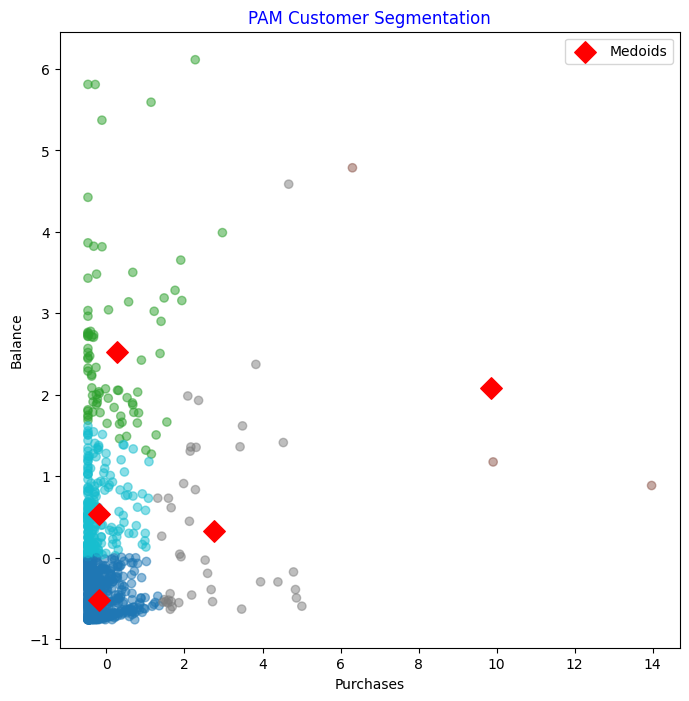

In [14]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(data2d.purchases, data2d['balance'], c = data2d.cluster, alpha = 0.5, cmap = 'tab10')
plt.scatter(medoids2d[:, 0], medoids2d[:, 1], marker = 'D', s = 120, color = 'red', zorder = 5, label = 'Medoids')
plt.xlabel('Purchases')
plt.ylabel('Balance')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()